In [2]:
import pandas as pd
# Library to manipulate matrices
import numpy as np
# Plotting library 
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import ipywidgets as widgets
%matplotlib inline
import plotly.express as px

In [3]:
#Loading PJM Hourly data
#data=pd.read_csv("PJME_hourly.csv")
data = pd.read_csv("PJME_hourly/PJME_hourly.csv")


In [4]:
#Analyzing data
data.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [5]:
#Analysing data
data.shape

(145366, 2)

In [6]:
#Analysing data
data.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


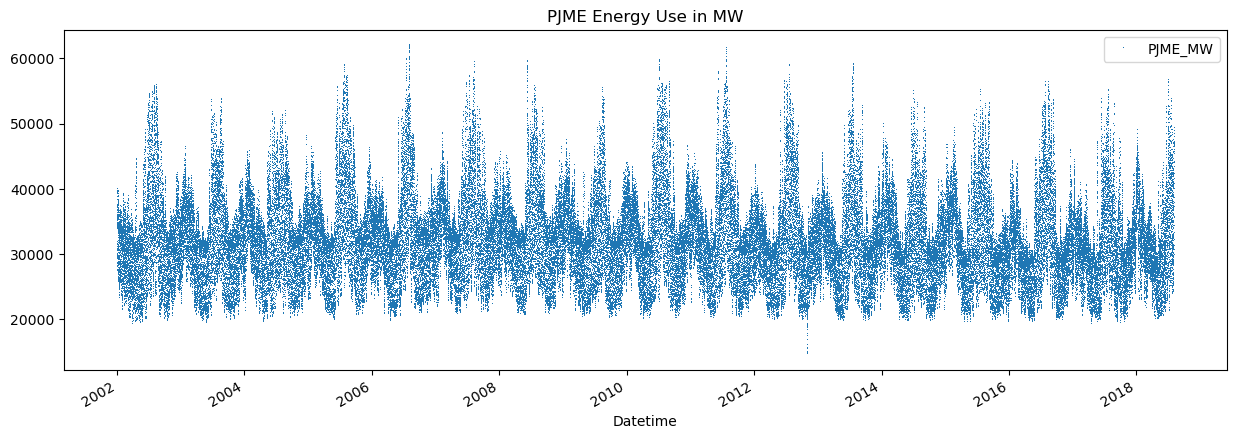

In [7]:
#Checking data types for columns
data.dtypes

#Datetime feature is object type, converting it to datetime
data["Datetime"]=pd.to_datetime(data["Datetime"])

#Setting Datetime as index to make panda operations easier
data_setindex=data.set_index("Datetime")

#Visulaizing Energy consumption as per datetime
data_setindex.plot(style=",", figsize=(15,5), title='PJME Energy Use in MW')
plt.show()
       

In [8]:
# Remove duplicate timestamps first
data_setindex = data_setindex[~data_setindex.index.duplicated(keep='first')]

# Check for missing timestamps
full_range = pd.date_range(start=data_setindex.index.min(), 
                           end=data_setindex.index.max(), freq='h')
missing = full_range.difference(data_setindex.index)
print(f"Missing timestamps: {len(missing)}")

# Reindex and impute
data_setindex = data_setindex.reindex(full_range)
data_setindex['PJME_MW'] = data_setindex['PJME_MW'].interpolate(method='time')
print(f"NaNs after imputation: {data_setindex.isna().sum().sum()}")

Missing timestamps: 30
NaNs after imputation: 0


30 missing hourly timestamps were detected in the dataset. These missing hours were not visible via `isna().sum()` as the rows were completely absent from the data.

Using `reindex()`, the missing hours were inserted as `NaN` rows to make the timeline continuous. These `NaN` values were then imputed using **time-weighted interpolation**, which estimates each missing value by considering its neighbouring previous and future data points — respecting the actual time gap between them

                     PJME_MW
2002-06-26 13:00:00  51677.0
2002-06-26 14:00:00  52637.0
2002-06-26 15:00:00  52938.0
2002-06-26 16:00:00  52894.0
2002-06-26 17:00:00  52148.0
...                      ...
2018-07-16 15:00:00  52742.0
2018-07-16 16:00:00  53408.0
2018-07-16 17:00:00  53764.0
2018-07-16 18:00:00  53352.0
2018-07-16 19:00:00  52226.0

[1320 rows x 1 columns]
1320


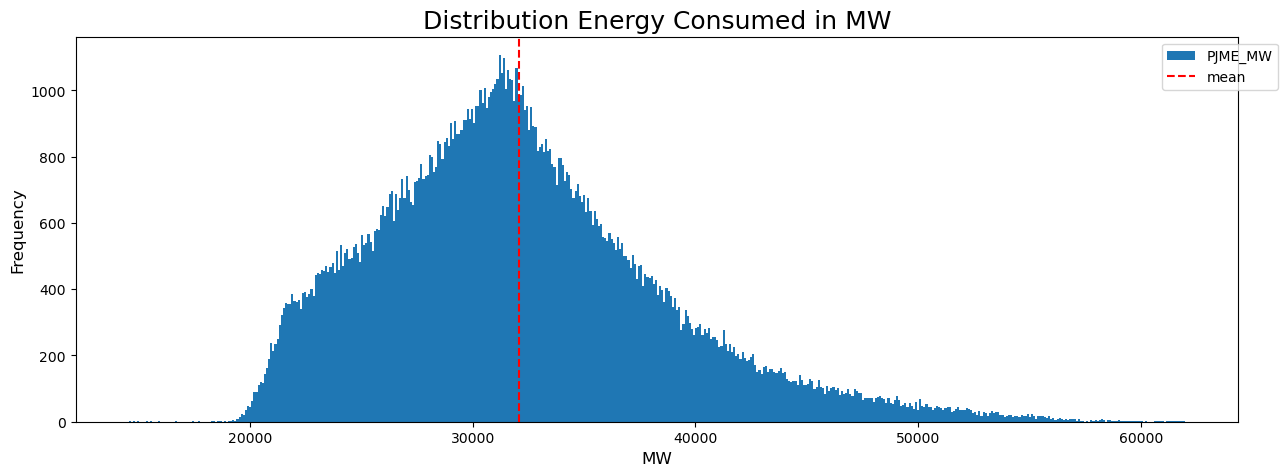

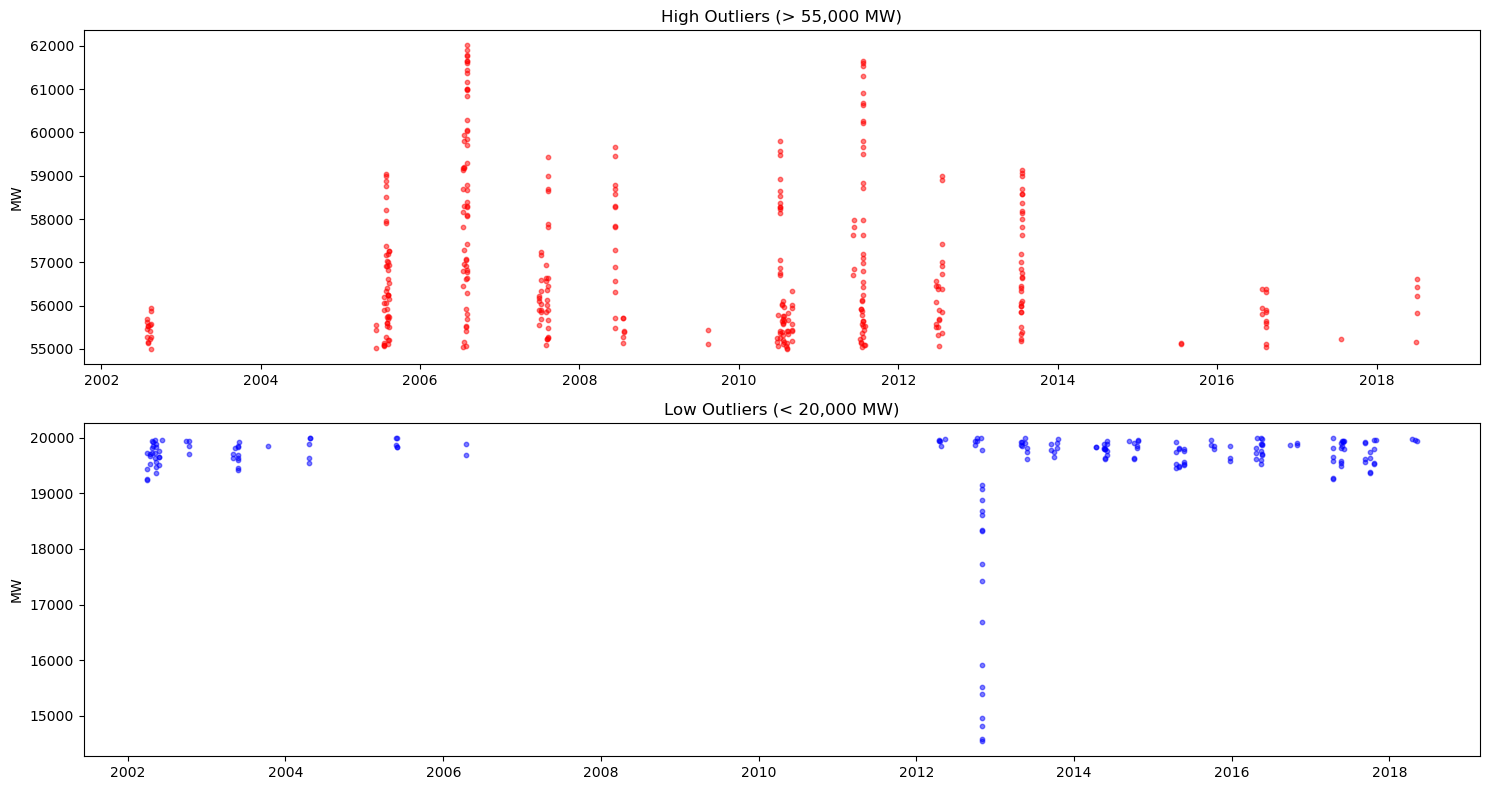

In [9]:
# Dealing with outliers

# Plot distribution of energy consumption to visually inspect spread and skewness
mean_MW = data_setindex['PJME_MW'].mean()
data_setindex['PJME_MW'].plot(figsize=(15,5), kind='hist', bins=500)
plt.title('Distribution Energy Consumed in MW', fontsize=18)
plt.xlabel('MW', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=mean_MW, color='r', linestyle='--', label='mean')
plt.legend(bbox_to_anchor=(1.04,1))

# Z-score measures how many standard deviations a value is from the mean
# Values with |z| > 3 are considered statistical outliers
z = np.abs((data_setindex['PJME_MW'] - data_setindex['PJME_MW'].mean()) / data_setindex['PJME_MW'].std())

# Filter and inspect outliers
outliers_z_score = data_setindex[z > 3]
print(outliers_z_score)
print(len(outliers_z_score))

# Separate outliers into high and low to understand their nature
high_outliers = data_setindex.query('PJME_MW > 55000')
low_outliers  = data_setindex.query('PJME_MW < 20000')

# Scatter plot to identify when outliers occur across the timeline
# High outliers recurring every summer suggest heatwave events
# Low outliers with an isolated extreme dip around 2012 suggest Hurricane Sandy
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].scatter(high_outliers.index, high_outliers['PJME_MW'],
                color='red', alpha=0.5, s=10)
axes[0].set_title('High Outliers (> 55,000 MW)')
axes[0].set_ylabel('MW')

axes[1].scatter(low_outliers.index, low_outliers['PJME_MW'],
                color='blue', alpha=0.5, s=10)
axes[1].set_title('Low Outliers (< 20,000 MW)')
axes[1].set_ylabel('MW')

plt.tight_layout()
plt.show()

# Remove Hurricane Sandy extreme dip — isolated infrastructure failure, not real demand
data_setindex = data_setindex[data_setindex['PJME_MW'] > 19000]

1,318 observations have Z-scores greater than 3, representing just 0.91% of the 145,366 total readings. As visualised in the scatter plots above, high outliers (above 55,000 MW) recur consistently every summer across the full 2002-2018 period, confirming these are genuine heatwave-driven demand spikes and are therefore retained. Low outliers however reveal two distinct behaviours: the majority of low values around 19,000-20,000 MW recur consistently across all years representing natural low demand periods and are retained, whilst an isolated extreme dip to ~14,544 MW in October 2012, observed nowhere else in the dataset, coincides precisely with Hurricane Sandy making landfall in the PJM East region, representing infrastructure failure rather than real demand and is therefore removed by filtering values below 19,000 MW. RobustScaler is selected for scaling as it is resistant to the retained outliers, unlike StandardScaler which would be skewed by the extreme summer peak values.

C:\Users\rettu\AppData\Local\Temp\ipykernel_31464\3803240325.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_monthly = data_setindex.resample("M").mean()


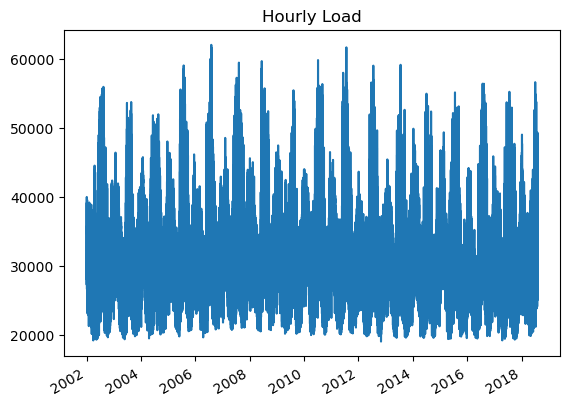

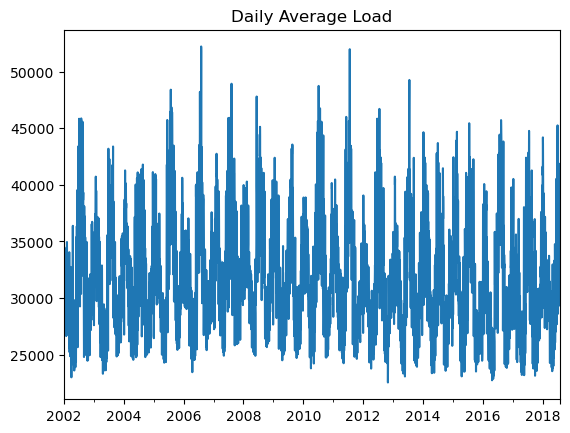

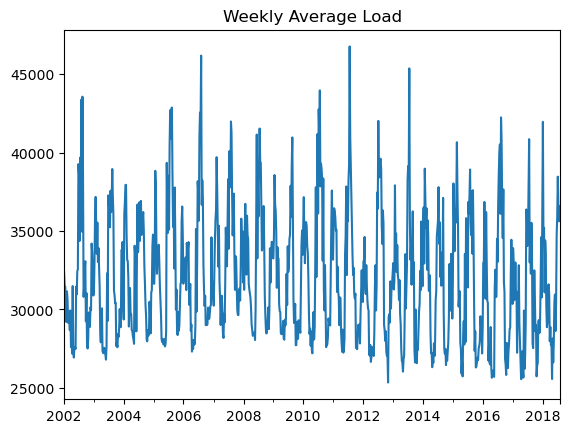

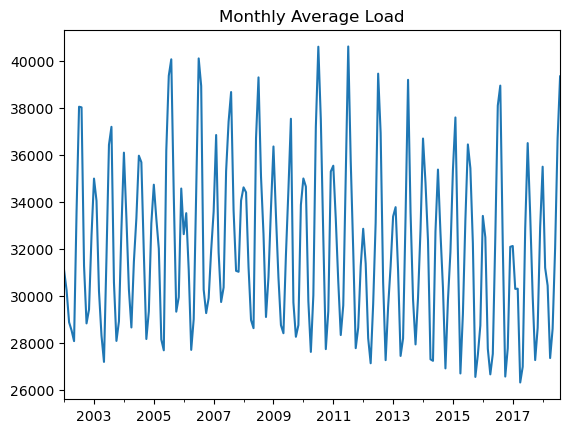

In [10]:
# Data is already at hourly frequency. Resampling is performed to analyze the data
# at different time scales (daily, weekly, monthly) using mean aggregation.

data_daily = data_setindex.resample("D").mean()
data_weekly = data_setindex.resample("W").mean()
data_monthly = data_setindex.resample("M").mean()

# Hourly
plt.figure()
data_setindex['PJME_MW'].plot(title="Hourly Load")

# Daily
plt.figure()
data_daily['PJME_MW'].plot(title="Daily Average Load")

# Weekly
plt.figure()
data_weekly['PJME_MW'].plot(title="Weekly Average Load")

# Monthly
plt.figure()
data_monthly['PJME_MW'].plot(title="Monthly Average Load")

plt.show()

The plots show that hourly data contains the most detailed information, including strong daily patterns and short term fluctuations, while daily, weekly, and monthly resampling progressively smooths the data and highlights broader trends but removes important temporal detail. Since electricity demand is highly influenced by hourly variations, especially daily cycles, using hourly data preserves the most relevant information for accurate forecasting. Therefore, hourly data is selected for modeling, while the resampled daily, weekly, and monthly data are used for exploratory analysis and understanding overall trends.

In [11]:
!pip install holidays

In [12]:
#Feature Engineering

import holidays

data_raw = data_setindex.copy()
data_featured = data_raw.copy()

# ── 1. Temporal ───────────────────────────────────────────────────────────────
data_featured['hour']        = data_featured.index.hour
data_featured['day_of_week'] = data_featured.index.dayofweek
data_featured['quarter']     = data_featured.index.quarter
data_featured['week']        = data_featured.index.isocalendar().week.values.astype(int)
data_featured['month']       = data_featured.index.month
data_featured['year']        = data_featured.index.year
data_featured['dayofyear']   = data_featured.index.dayofyear

# ── 2. Cyclical Encoding ──────────────────────────────────────────────────────
data_featured['hour_sin']  = np.sin(2 * np.pi * data_featured['hour'] / 24)
data_featured['hour_cos']  = np.cos(2 * np.pi * data_featured['hour'] / 24)
data_featured['month_sin'] = np.sin(2 * np.pi * data_featured['month'] / 12)
data_featured['month_cos'] = np.cos(2 * np.pi * data_featured['month'] / 12)

# ── 3. Holidays ───────────────────────────────────────────────────────────────
us_holidays = holidays.US()
data_featured['is_holiday']      = data_featured.index.normalize().map(
                                    lambda x: 1 if x in us_holidays else 0)
data_featured['days_to_holiday'] = data_featured.index.map(
                                    lambda x: min(abs((x.date() - h).days) 
                                    for h in us_holidays))

# ── 4. Statistical ────────────────────────────────────────────────────────────
data_featured['ma_7d']       = data_featured['PJME_MW'].rolling(window=7*24).mean()
data_featured['ma_30d']      = data_featured['PJME_MW'].rolling(window=30*24).mean()
data_featured['ma_90d']      = data_featured['PJME_MW'].rolling(window=90*24).mean()
data_featured['roll_std_7d'] = data_featured['PJME_MW'].rolling(window=7*24).std()
data_featured['roll_min_7d'] = data_featured['PJME_MW'].rolling(window=7*24).min()
data_featured['roll_max_7d'] = data_featured['PJME_MW'].rolling(window=7*24).max()
data_featured['ewma_7d']     = data_featured['PJME_MW'].ewm(span=7*24).mean()
data_featured['ewma_30d']    = data_featured['PJME_MW'].ewm(span=30*24).mean()

# ── 5. Lag Features ───────────────────────────────────────────────────────────
data_featured['lag_1h']   = data_featured['PJME_MW'].shift(1)
data_featured['lag_24h']  = data_featured['PJME_MW'].shift(24)
data_featured['lag_168h'] = data_featured['PJME_MW'].shift(168)

# ── 6. Domain Specific (external data not available) ─────────────────────────
# Temperature and daylight hours require external weather data — skipped

# ── Drop NaNs ─────────────────────────────────────────────────────────────────
data_featured.dropna(inplace=True)
print(f"Shape: {data_featured.shape}")
print(f"Features: {data_featured.columns.tolist()}")

print(f"Shape: {data_raw.shape}")
print(f"Features: {data_raw.columns.tolist()}")

Shape: (143218, 25)
Features: ['PJME_MW', 'hour', 'day_of_week', 'quarter', 'week', 'month', 'year', 'dayofyear', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_holiday', 'days_to_holiday', 'ma_7d', 'ma_30d', 'ma_90d', 'roll_std_7d', 'roll_min_7d', 'roll_max_7d', 'ewma_7d', 'ewma_30d', 'lag_1h', 'lag_24h', 'lag_168h']
Shape: (145377, 1)
Features: ['PJME_MW']


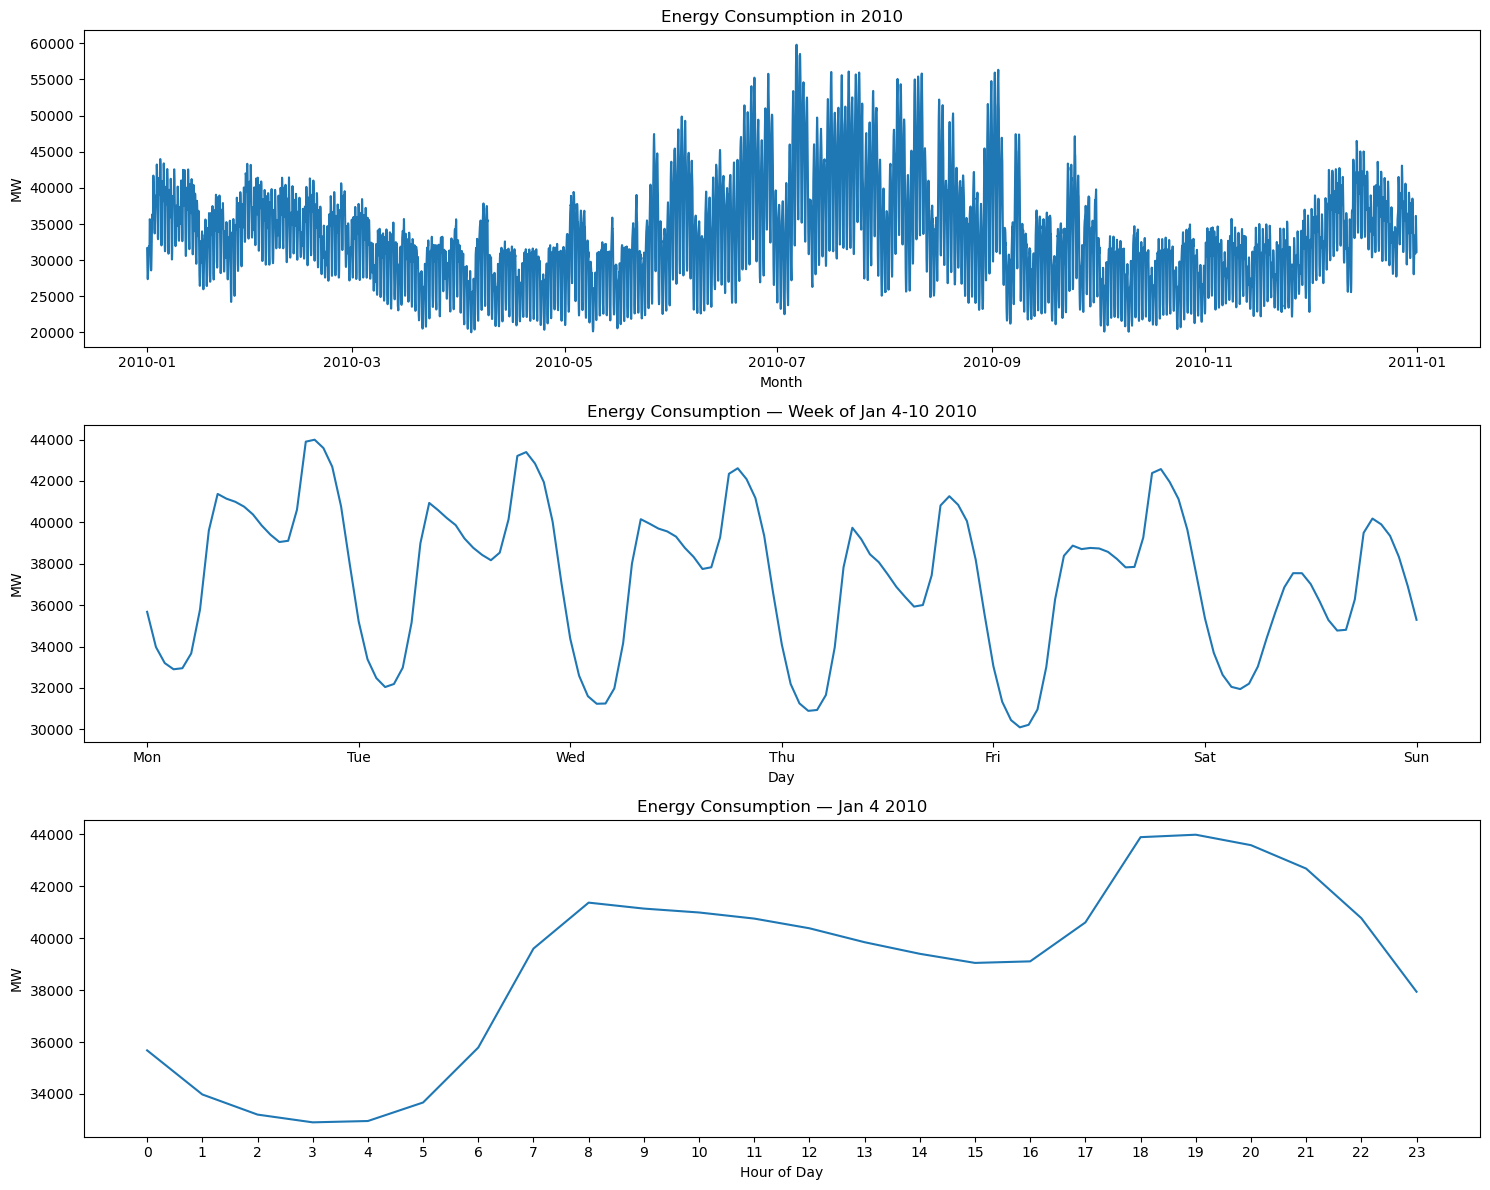

In [13]:
# Plotting energy consumption against year, week and day to observe patterns
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Full year — to observe monthly pattern
axes[0].plot(data_featured[data_featured.index.year == 2010]['PJME_MW'])
axes[0].set_title('Energy Consumption in 2010')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MW')

# One week — to observe daily pattern
week_data = data_featured[(data_featured.index >= '2010-01-04') & 
                           (data_featured.index <= '2010-01-10')]
axes[1].plot(week_data.index, week_data['PJME_MW'])
axes[1].set_title('Energy Consumption — Week of Jan 4-10 2010')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('MW')
axes[1].set_xticks(pd.date_range('2010-01-04', '2010-01-10', freq='D'))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# One day — to observe hourly pattern
day_data = data_featured[data_featured.index.date == pd.Timestamp('2010-01-04').date()]
axes[2].plot(day_data.index.hour, day_data['PJME_MW'])
axes[2].set_title('Energy Consumption — Jan 4 2010')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('MW')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [14]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


The three plots above visualise energy consumption patterns at different time scales. The yearly plot (2010) reveals a clear seasonal pattern — consumption peaks during June, July and August, likely driven by air conditioning and other cooling systems during summer heat, with a secondary smaller peak during winter months (November-January) attributable to heating demand. The lowest consumption periods occur during spring and autumn when temperatures are mild and neither heating nor cooling is heavily required. The weekly plot shows a repeating daily cycle across the 7 days, with noticeable dips during weekends (Jan 9-10) compared to weekdays, reflecting reduced industrial and commercial activity. The daily plot (Jan 4 2010) reveals a clear hourly pattern — consumption is lowest in the early morning hours (around 3-4am), rises sharply as the working day begins, peaks in the afternoon and early evening, then gradually declines overnight. These patterns confirm that energy consumption is strongly influenced by time of day, day of week and month of year, justifying the temporal features engineered in the previous section.

                 Spearman Correlation
is_holiday                   0.029844
month_cos                    0.048376
month_sin                    0.050869
dayofyear                    0.067666
month                        0.068156
week                         0.068346
year                         0.076218
quarter                      0.078621
days_to_holiday              0.085816
ma_90d                       0.093328
day_of_week                  0.192467
hour_cos                     0.302218
roll_std_7d                  0.318450
ma_30d                       0.464961
hour_sin                     0.474189
roll_min_7d                  0.478115
ewma_30d                     0.492235
hour                         0.514107
roll_max_7d                  0.514279
ma_7d                        0.546224
ewma_7d                      0.588197
lag_168h                     0.802420
lag_24h                      0.880315
lag_1h                       0.967822


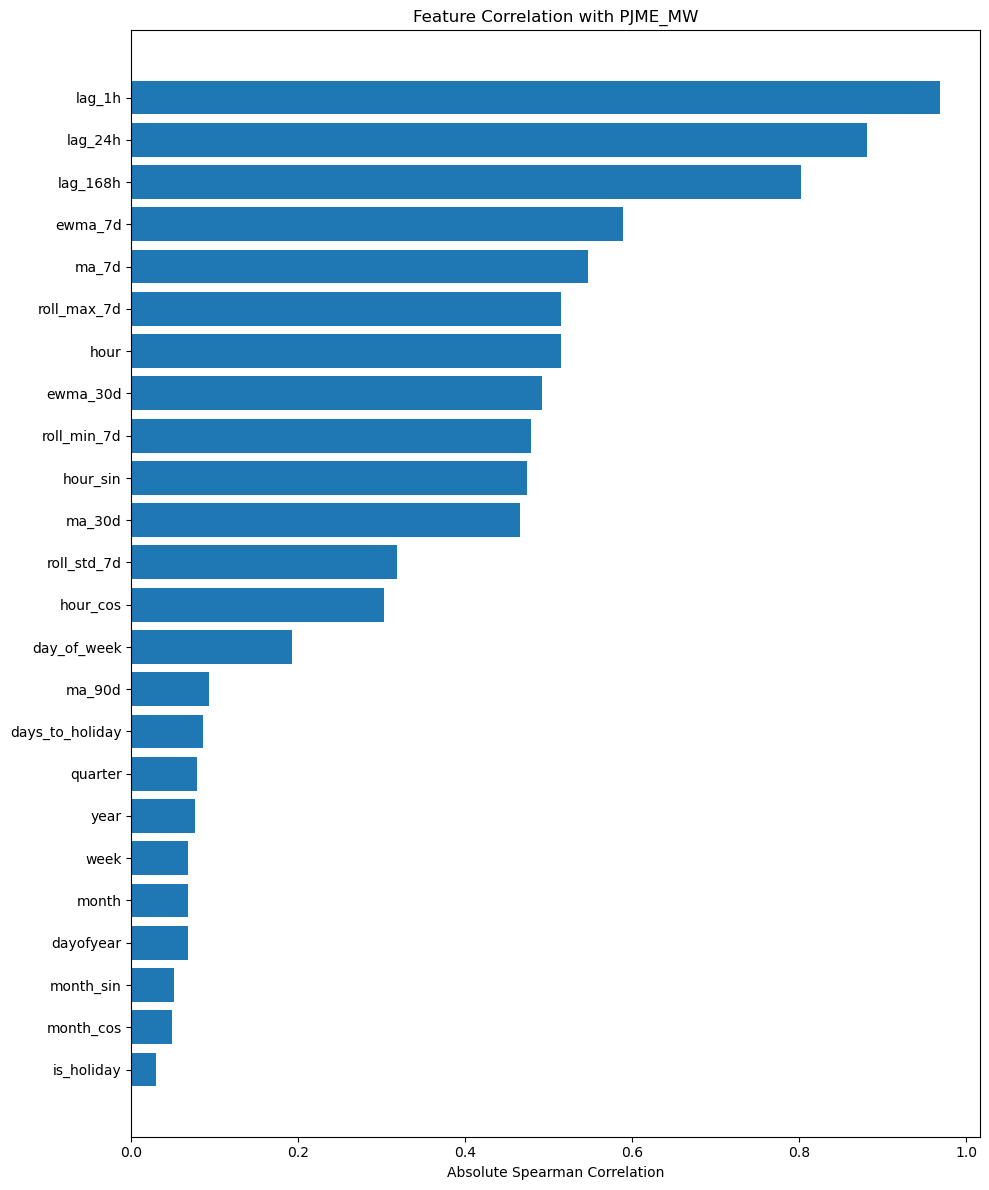

In [15]:
# Feature selection is performed using three methods:
# 1) Filter method (Spearman correlation) — measures the statistical relationship 
#    between each feature and the target variable, independent of any model.
# 2) Wrapper method (RFE) — applied after model selection, RFE iteratively removes 
#    the least important features and evaluates model performance on each subset.
# 3) Embedded method — utilises the built-in feature importance of Linear Regression 
#    (coefficients) and XGBoost (gain-based importance), which are learned during 
#    training. Results from all three methods will later be compared to identify the most 
#    consistently important features.

# Feature Selection using Spearman Correlation
from scipy.stats import spearmanr

# Calculate Spearman correlation of each feature with target
correlations = {}
for col in data_featured.columns:
    if col != 'PJME_MW':
        corr, _ = spearmanr(data_featured['PJME_MW'], data_featured[col])
        correlations[col] = corr

# Convert to dataframe and sort by absolute correlation
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Spearman Correlation'])
corr_df = corr_df.abs().sort_values('Spearman Correlation', ascending=True)

# Print all coefficients
print(corr_df.to_string())

# Bar chart of all correlations
plt.figure(figsize=(10, 12))
plt.barh(corr_df.index, corr_df['Spearman Correlation'])
plt.xlabel('Absolute Spearman Correlation')
plt.title('Feature Correlation with PJME_MW')
plt.tight_layout()
plt.show()


As observed in the bar chart above, lag features exhibit the highest Spearman correlation with PJME_MW, which is expected as previous consumption values are the strongest indicator of future demand. lag_1h shows the highest correlation, as the most recent hour is the most direct indicator of the next, followed by lag_24h and lag_168h representing 1 day and 1 week prior respectively. Statistical features such as ewma_7d, ma_7d and roll_max_7d follow, capturing short-term trends in consumption. Temporal features such as hour and day_of_week show moderate correlation, whilst cyclical encodings (month_sin, month_cos, dow_cos) and is_holiday show near-zero Spearman coefficients. This does not imply these features are uninformative, rather it reflects a fundamental limitation of Spearman's correlation, which only measures monotonic relationships where values consistently increase or decrease together. Cyclical features such as month_sin and month_cos follow a sine wave pattern where the first and last values are close together, meaning the relationship with the target is not monotonic but circular. Spearman cannot capture this circular structure, causing it to underestimate the true importance of these features despite the clear seasonal patterns observed in the plots above.

In [16]:
from sklearn.model_selection import TimeSeriesSplit

In [17]:
!pip install xgboost

In [26]:
# Define features and target

X = data_featured.drop(columns=['PJME_MW'])
y = data_featured['PJME_MW']

Fold 1 | Train: 99418 | Val: 8760 | Test: 8760
Fold 2 | Train: 108178 | Val: 8760 | Test: 8760
Fold 3 | Train: 116938 | Val: 8760 | Test: 8760
Fold 4 | Train: 125698 | Val: 8760 | Test: 8760


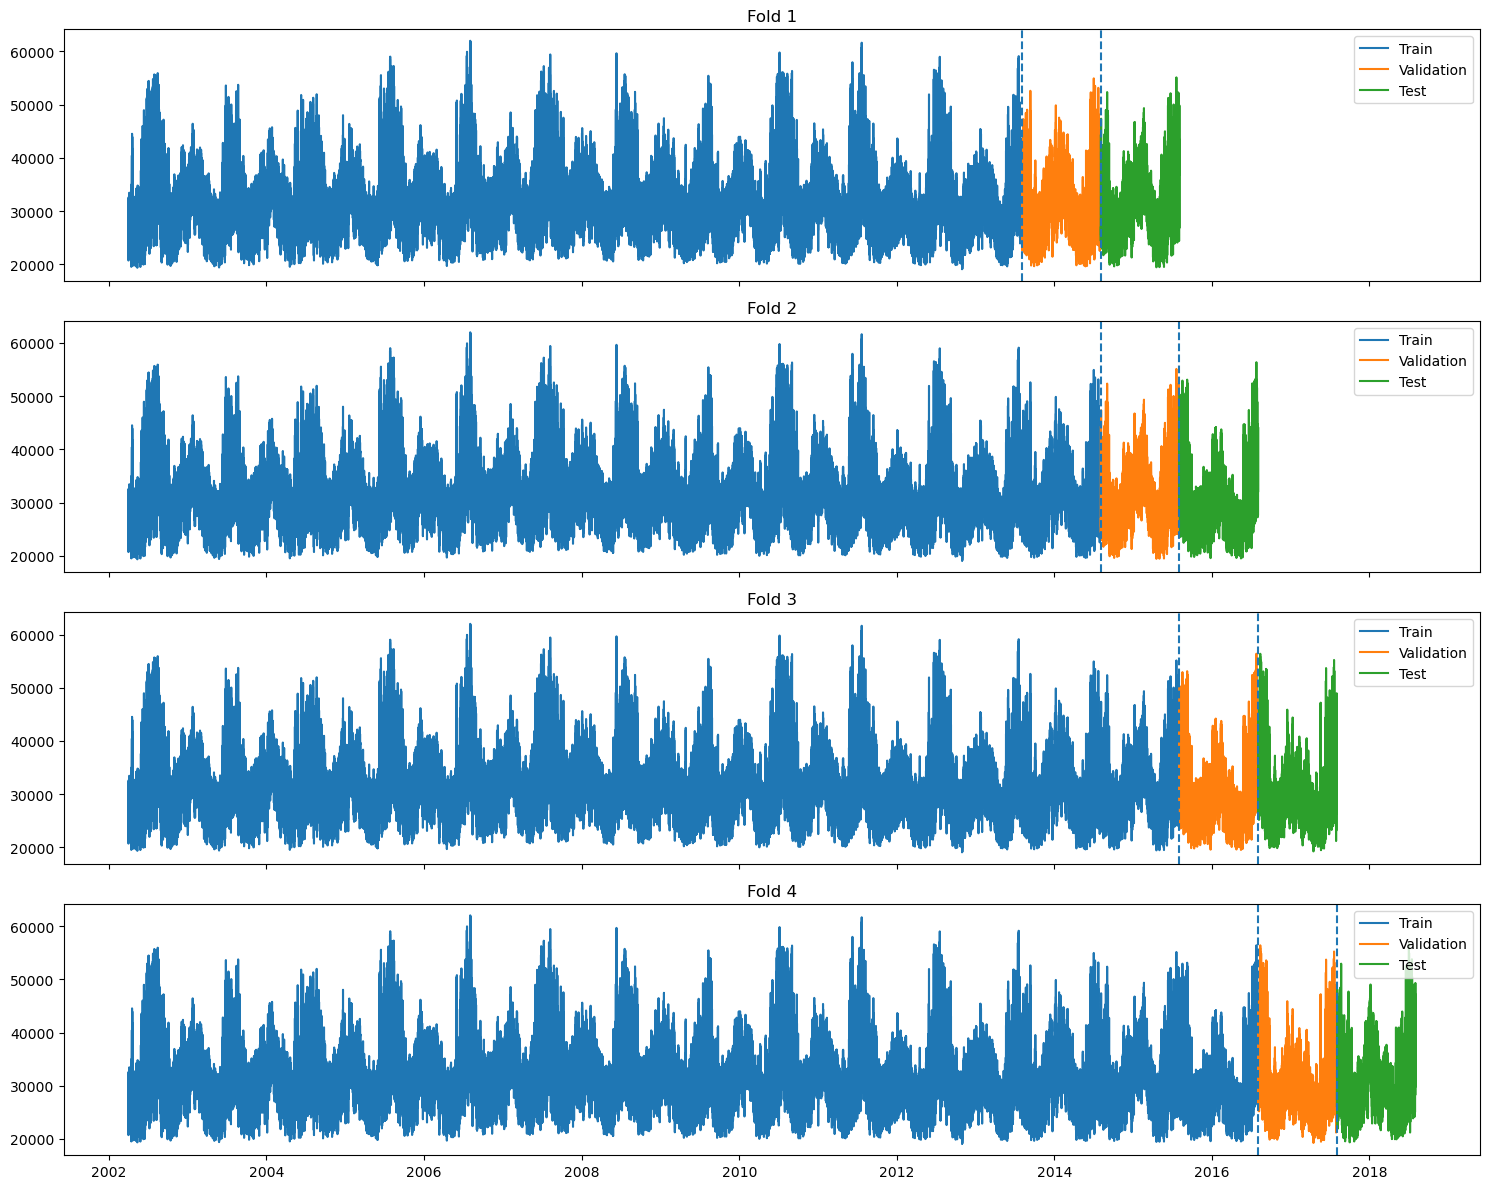

In [29]:
test_size = 8760
cv_data = data_featured

tss = TimeSeriesSplit(
    n_splits=5,
    gap=0,
    test_size=test_size
)

valid_folds = []

for fold, (train_index, val_index) in enumerate(tss.split(X)):
    test_start = val_index[-1] + 1
    test_end = test_start + test_size

    if test_end <= len(cv_data):
        valid_folds.append((fold, train_index, val_index, test_start, test_end))

fig, axs = plt.subplots(len(valid_folds), 1, figsize=(15, 12), sharex=True)

if len(valid_folds) == 1:
    axs = [axs]

for i, (fold, train_index, val_index, test_start, test_end) in enumerate(valid_folds):
    X_train = X.iloc[train_index]
    X_val = X.iloc[val_index]
    X_test = X.iloc[test_start:test_end]
   
    train = cv_data.iloc[train_index]
    val = cv_data.iloc[val_index]
    test = cv_data.iloc[test_start:test_end]

    scaler = RobustScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    ax = axs[i]
    ax.plot(train.index, train['PJME_MW'], label='Train')
    ax.plot(val.index, val['PJME_MW'], label='Validation')
    ax.plot(test.index, test['PJME_MW'], label='Test')

    ax.axvline(val.index.min(), linestyle='--')
    ax.axvline(test.index.min(), linestyle='--')

    ax.set_title(f'Fold {fold+1}')
    ax.legend()

    print(f"Fold {fold+1} | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

plt.tight_layout()
plt.show()

In [64]:
!pip install xgboost

Fold 1 RMSE: 1039.22, MAE: 795.16
Fold 2 RMSE: 1025.83, MAE: 790.04
Fold 3 RMSE: 1024.28, MAE: 794.17
Fold 4 RMSE: 985.58, MAE: 769.93

Average RMSE: 1018.7280023675303
Average MAE: 787.3235666343105


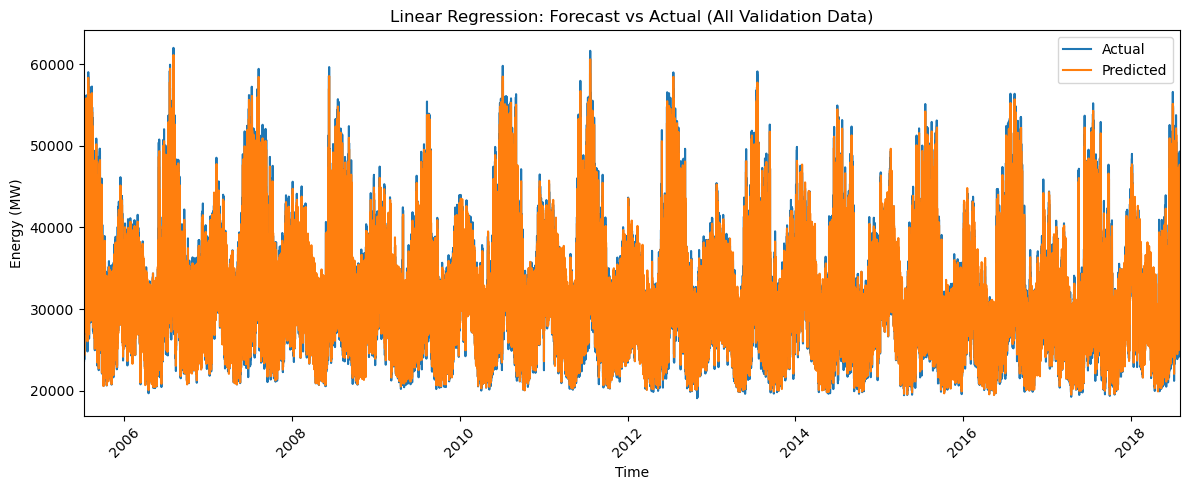

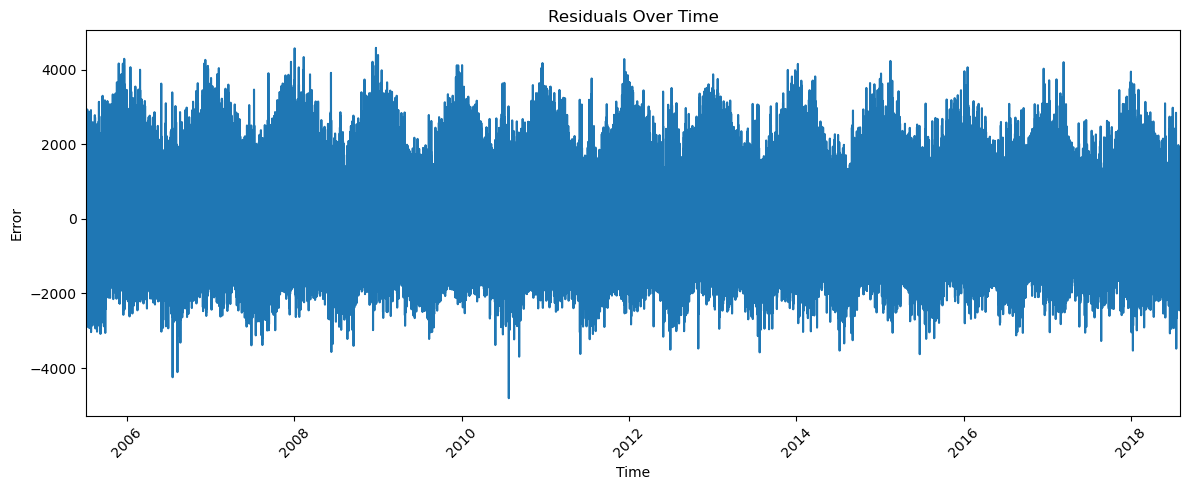

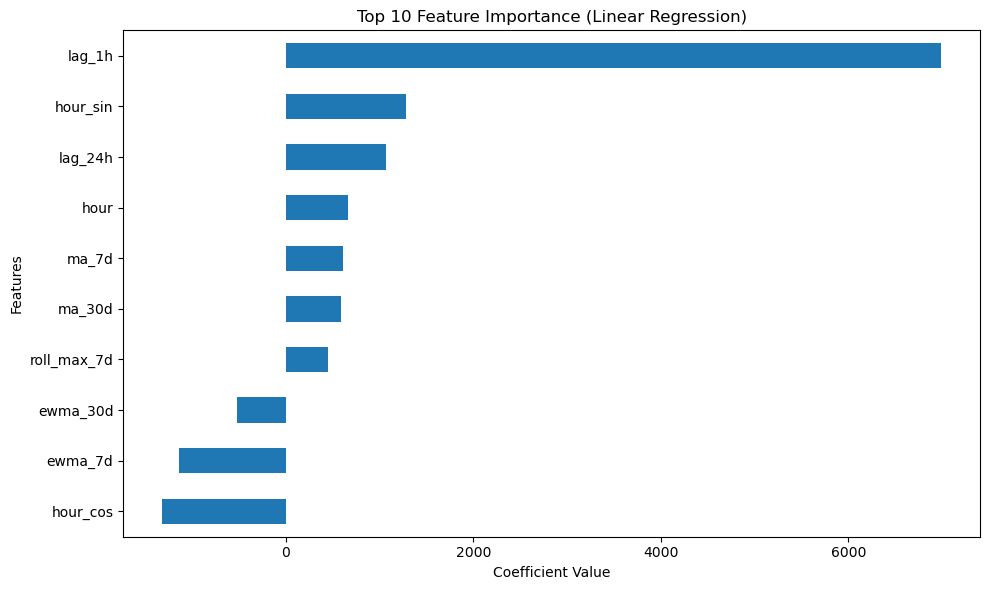


Interpretation:
The model captures general trends but struggles with peak values.
Lag-based features are most important, showing strong temporal patterns.


In [47]:
# PART 3: LINEAR REGRESSION 

# Import libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. DATA PREPARATION

data_featured = data_featured.sort_index()
data_featured.index = pd.to_datetime(data_featured.index)

X = data_featured.drop(columns=['PJME_MW'])
y = data_featured['PJME_MW']

# 2. TIME SERIES SPLIT (4 FOLDS)

tscv = TimeSeriesSplit(n_splits=4)

lr_rmse = []
lr_mae = []

all_val = []
all_pred = []

# 3. MODEL TRAINING LOOP

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    # Split data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Scaling (handles outliers)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predict
    pred = model.predict(X_val_scaled)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)

    lr_rmse.append(rmse)
    lr_mae.append(mae)

    print(f"Fold {fold+1} RMSE: {rmse:.2f}, MAE: {mae:.2f}")

    # Store for full timeline
    all_val.append(y_val)
    all_pred.append(pd.Series(pred, index=y_val.index))

# 4. FINAL PERFORMANCE
print("\nAverage RMSE:", np.mean(lr_rmse))
print("Average MAE:", np.mean(lr_mae))

# 5. COMBINE ALL FOLDS

all_val = pd.concat(all_val).sort_index()
all_pred = pd.concat(all_pred).sort_index()
all_pred = all_pred.reindex(all_val.index)

# 6. FULL TIMELINE PLOT

plt.figure(figsize=(12,5))
plt.plot(all_val.index, all_val, label="Actual")
plt.plot(all_pred.index, all_pred, label="Predicted")

plt.xlim(all_val.index.min(), all_val.index.max())

plt.title("Linear Regression: Forecast vs Actual (All Validation Data)")
plt.xlabel("Time")
plt.ylabel("Energy (MW)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. RESIDUAL ANALYSIS

residuals = all_val - all_pred

plt.figure(figsize=(12,5))
plt.plot(all_val.index, residuals)

plt.xlim(all_val.index.min(), all_val.index.max())

plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. FEATURE IMPORTANCE (AVERAGED)

coef_list = []

for train_idx, val_idx in tscv.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    coef_list.append(model.coef_)

coef_df = pd.DataFrame(coef_list, columns=X.columns)
avg_coef = coef_df.mean()

top_features = avg_coef.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_coef[top_features.index].sort_values().plot(kind='barh')

plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("The model captures general trends but struggles with peak values.")
print("Lag-based features are most important, showing strong temporal patterns.")


Linear Regression:Forecast vs Actual Graph:This plot compares the actual energy consumption with the predicted values across all validation folds. The model is able to capture the overall trend and seasonal patterns in the data, as seen by the close alignment between the two curves. However, there are noticeable deviations during peak demand periods, indicating that the linear model has limitations in capturing more complex, nonlinear behavior. 

Residuals Over Time Graph:This plot shows the residuals (difference between actual and predicted values) over time. Ideally, residuals should be randomly distributed around zero, indicating that the model has captured the underlying patterns effectively. In this case, the residuals are mostly centered around zero, suggesting a reasonable model fit. However, some larger deviations can be observed during certain periods, especially around peaks, indicating that the linear model struggles to fully capture extreme variations. 

Top 10 Feature Importance Graph:This plot shows the top features influencing the linear regression model based on their coefficient values. Lag-based features, particularly lag_1h and lag_24h, have the highest impact, indicating strong short-term temporal dependency in energy consumption. Time-based features such as hour_sin and hour_cos also contribute, capturing daily cyclical patterns. Moving average features provide additional smoothing information, though their impact is relatively smaller. Overall, the results highlight that recent past values and daily cycles are the most important factors in predicting energy demand.



   n_estimators  max_depth  learning_rate        rmse
0           100          3           0.10  658.013181
1           200          5           0.05  487.442516
2           300          6           0.03  460.587335
3           300          8           0.03  426.458746
4           300         10           0.03  419.095318


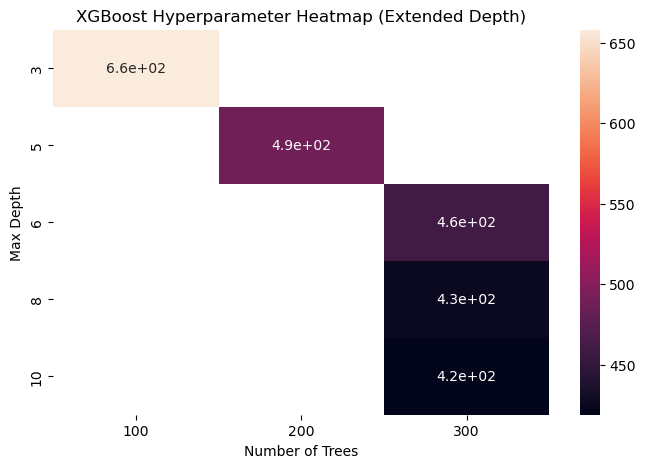


Best Parameters: n_estimators     300.000000
max_depth         10.000000
learning_rate      0.030000
rmse             419.095318
Name: 4, dtype: float64
Fold 1 RMSE: 536.66, MAE: 307.85
Fold 2 RMSE: 361.24, MAE: 251.37
Fold 3 RMSE: 397.09, MAE: 280.82
Fold 4 RMSE: 381.40, MAE: 280.60

Average RMSE: 419.09531847377974
Average MAE: 280.1620916289266


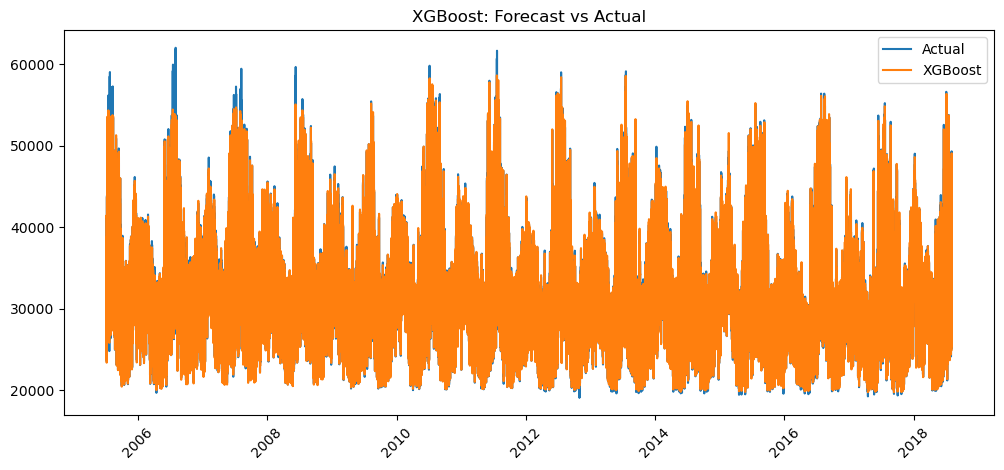

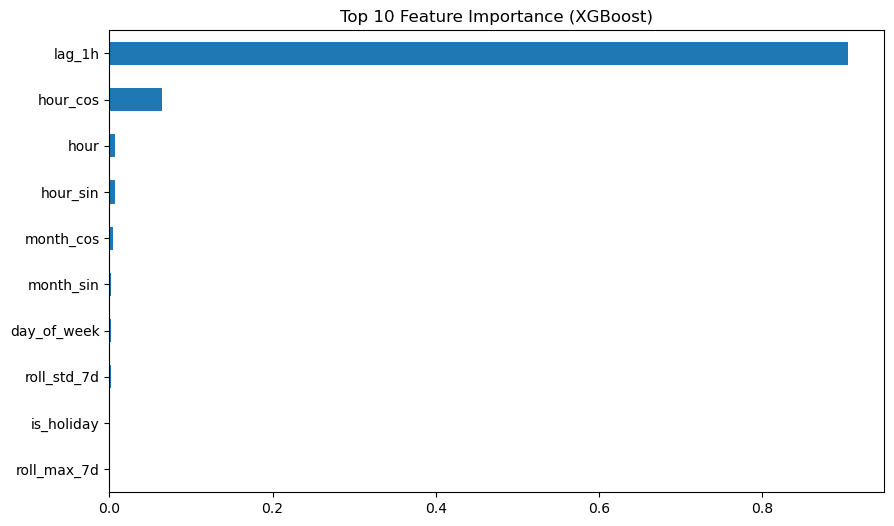

In [49]:
# =========================================
# XGBOOST WITH EXTENDED DEPTH SEARCH
# =========================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------------------------
# 1. DATA
# -----------------------------------------

data_featured = data_featured.sort_index()
data_featured.index = pd.to_datetime(data_featured.index)

X = data_featured.drop(columns=['PJME_MW'])
y = data_featured['PJME_MW']


# -----------------------------------------
# 2. TIME SERIES SPLIT
# -----------------------------------------

tscv = TimeSeriesSplit(n_splits=4)


# -----------------------------------------
# 3. EXTENDED HYPERPARAMETER GRID
# -----------------------------------------

param_grid = [
    (100, 3, 0.1),
    (200, 5, 0.05),
    (300, 6, 0.03),
    (300, 8, 0.03),
    (300, 10, 0.03)
]

results = []

for n, d, lr in param_grid:

    fold_rmse = []

    for train_idx, val_idx in tscv.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(
            n_estimators=n,
            max_depth=d,
            learning_rate=lr,
            random_state=42
        )

        model.fit(X_train, y_train)
        pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, pred))
        fold_rmse.append(rmse)

    results.append([n, d, lr, np.mean(fold_rmse)])


# Results table
results_df = pd.DataFrame(results, columns=[
    'n_estimators', 'max_depth', 'learning_rate', 'rmse'
])

print(results_df)


# -----------------------------------------
# 4. HEATMAP
# -----------------------------------------

pivot = results_df.pivot(index='max_depth', columns='n_estimators', values='rmse')

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True)
plt.title("XGBoost Hyperparameter Heatmap (Extended Depth)")
plt.xlabel("Number of Trees")
plt.ylabel("Max Depth")
plt.show()


# -----------------------------------------
# 5. BEST PARAMETERS
# -----------------------------------------

best = results_df.loc[results_df['rmse'].idxmin()]
print("\nBest Parameters:", best)


# -----------------------------------------
# 6. FINAL MODEL (CROSS VALIDATION)
# -----------------------------------------

xgb_rmse = []
xgb_mae = []

all_val = []
all_pred = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=int(best['n_estimators']),
        max_depth=int(best['max_depth']),
        learning_rate=best['learning_rate'],
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)

    xgb_rmse.append(rmse)
    xgb_mae.append(mae)

    print(f"Fold {fold+1} RMSE: {rmse:.2f}, MAE: {mae:.2f}")

    all_val.append(y_val)
    all_pred.append(pd.Series(pred, index=y_val.index))


print("\nAverage RMSE:", np.mean(xgb_rmse))
print("Average MAE:", np.mean(xgb_mae))


# -----------------------------------------
# 7. PLOT
# -----------------------------------------

all_val = pd.concat(all_val).sort_index()
all_pred = pd.concat(all_pred).sort_index()

plt.figure(figsize=(12,5))
plt.plot(all_val.index, all_val, label="Actual")
plt.plot(all_pred.index, all_pred, label="XGBoost")

plt.title("XGBoost: Forecast vs Actual")
plt.legend()
plt.xticks(rotation=45)
plt.show()


# -----------------------------------------
# 8. FEATURE IMPORTANCE
# -----------------------------------------

importance = model.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)

top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

The hyperparameter heatmap illustrates how different combinations of model complexity affect prediction accuracy, measured using RMSE. As observed, lower depths such as 3 result in high error, indicating underfitting due to the model being too simple to capture the underlying patterns in the data. As the max_depth increases from 5 to 10, the RMSE consistently decreases, demonstrating that deeper trees allow the model to better learn complex, nonlinear relationships and temporal dependencies present in energy consumption data. The best performance is achieved at n_estimators = 300 and max_depth = 10, with the lowest RMSE of approximately 419, indicating this combination provides the most accurate predictions. This suggests that increasing both the number of trees and the depth improves model learning capacity. However, while deeper models perform better within this tested range, excessively large depths may eventually lead to overfitting, so the selected parameters represent a balance between model complexity and generalization.
